In [1]:
#TASK 1: TIME SERIES ANALYSIS (Stock Prices Dataset)

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


In [2]:
#Load the dataset
df_stock = pd.read_csv(r"C:\Users\user\Documents\2) Stock Prices Data Set.csv")
print(df_stock.head())


df_stock.head()

  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [3]:
# Clean column names
df_stock.columns = df_stock.columns.str.strip().str.lower()

# Convert date column and set as index
df_stock['date'] = pd.to_datetime(df_stock['date'])
df_stock.set_index('date', inplace=True)

df_stock.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAL,25.0700,25.8200,25.0600,25.3600,8998943
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-02,AAP,110.3600,111.8800,109.2900,109.7400,542711
2014-01-02,ABBV,52.1200,52.3300,51.5200,51.9800,4569061
2014-01-02,ABC,70.1100,70.2300,69.4800,69.8900,1148391


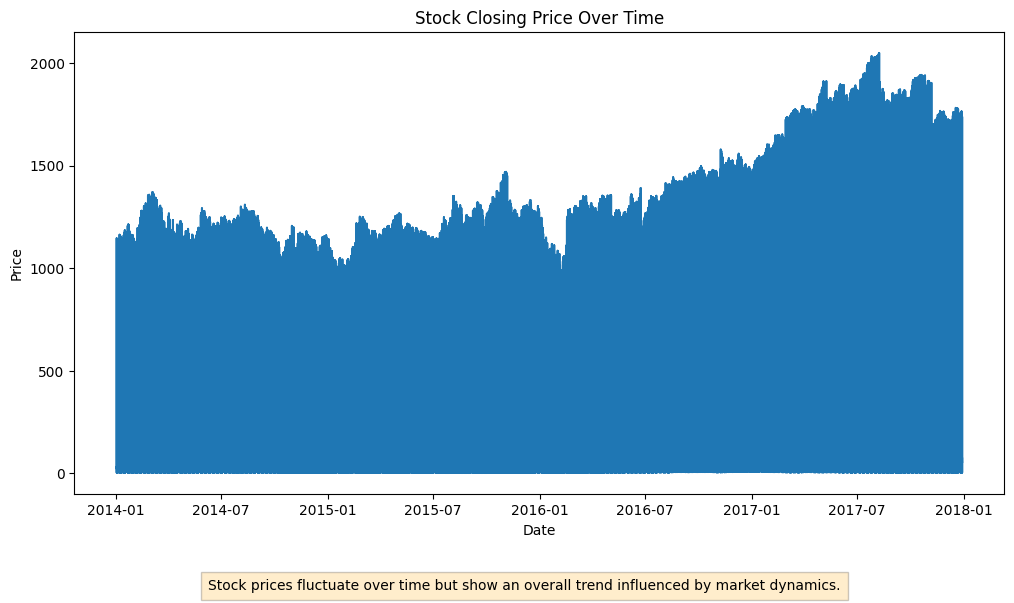

In [4]:
#Plot Time Series
plt.figure(figsize=(12,6))
plt.plot(df_stock['close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.figtext(0.5, -0.05,
            "Stock prices fluctuate over time but show an overall trend influenced by market dynamics.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()




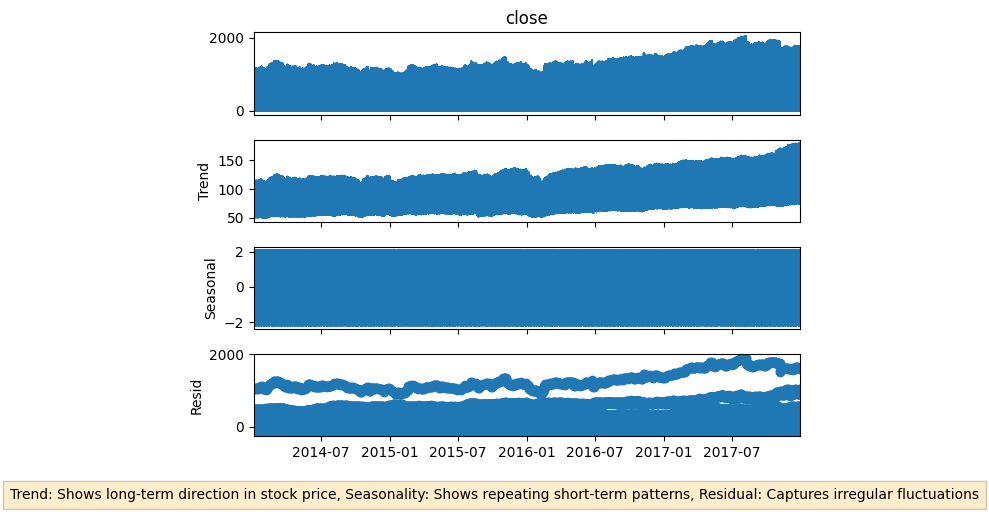

In [5]:
#Decomposition (Trend, Seasonality, Residual)
decomposition = seasonal_decompose(df_stock['close'], model='additive', period=30)
decomposition.plot()
plt.figtext(0.5, -0.05,
            "Trend: Shows long-term direction in stock price, Seasonality: Shows repeating short-term patterns, Residual: Captures irregular fluctuations",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()


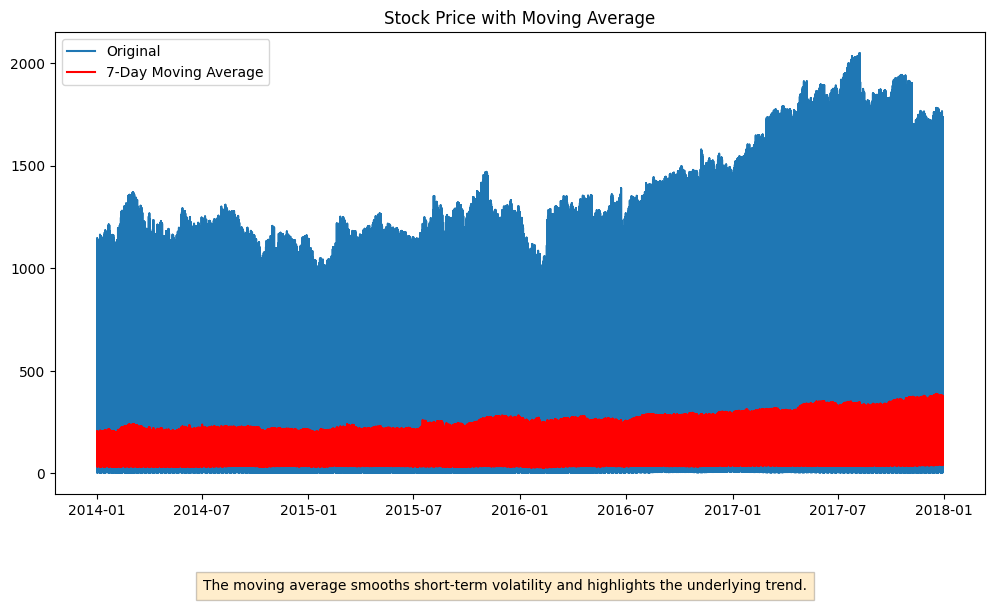

In [6]:
#Moving Average
df_stock['moving_avg'] = df_stock['close'].rolling(window=7).mean()

plt.figure(figsize=(12,6))
plt.plot(df_stock['close'], label='Original')
plt.plot(df_stock['moving_avg'], label='7-Day Moving Average', color='red')
plt.legend()
plt.title("Stock Price with Moving Average")
plt.figtext(0.5, -0.05,
            "The moving average smooths short-term volatility and highlights the underlying trend.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

plt.show()



In [7]:
#TASK 2: K-MEANS CLUSTERING (Customer Churn Dataset)

#Load Datasets
df_churn20 = pd.read_csv (r"C:\Users\user\Documents\churn-bigml-20.csv") 
df_churn80 = pd.read_csv (r"C:\Users\user\Documents\churn-bigml-80.csv")
print(df_churn20.head())
print(df_churn80.head())

#Merge Datasets
df_churn = pd.concat([df_churn20, df_churn80], axis=0)
print(df_churn.shape)


  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   
3                      0              110.4              103   
4                      0              119.3              117   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80             29.89   
1             21.95   

In [ ]:

#Clean Dataset
df_churn.info()
df_churn.isnull().sum()
df_churn.duplicated().sum()

# Standardize column names
df_churn.columns = df_churn.columns.str.strip().str.lower().str.replace(" ", "_")
df_churn.head()

# Handle missing values 
df_churn = df_churn.dropna()  
# Remove duplicates
df_churn = df_churn.drop_duplicates()

print(df_churn.columns)

<class 'pandas.core.frame.DataFrame'>
Index: 3333 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   3333 non-null   object 
 1   Account length          3333 non-null   int64  
 2   Area code               3333 non-null   int64  
 3   International plan      3333 non-null   object 
 4   Voice mail plan         3333 non-null   object 
 5   Number vmail messages   3333 non-null   int64  
 6   Total day minutes       3333 non-null   float64
 7   Total day calls         3333 non-null   int64  
 8   Total day charge        3333 non-null   float64
 9   Total eve minutes       3333 non-null   float64
 10  Total eve calls         3333 non-null   int64  
 11  Total eve charge        3333 non-null   float64
 12  Total night minutes     3333 non-null   float64
 13  Total night calls       3333 non-null   int64  
 14  Total night charge      3333 non-null   float

In [9]:
#Feature Selection
features = ['total_day_minutes', 'total_eve_minutes', 'total_night_minutes']
X = df_churn[features]

In [10]:
#Standardize Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

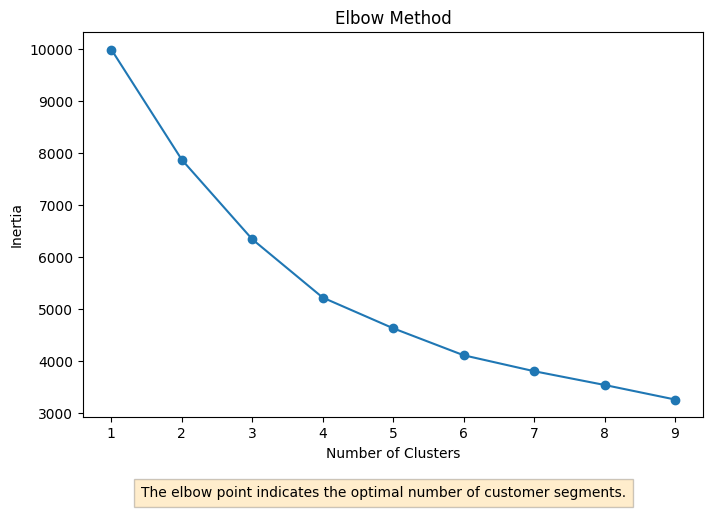

In [11]:
#Elbow Method to Find Optimal Clusters
from sklearn.cluster import KMeans

inertia = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.figtext(0.5, -0.05,
            "The elbow point indicates the optimal number of customer segments.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.show()







In [12]:
#Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df_churn['cluster'] = kmeans.fit_predict(X_scaled)

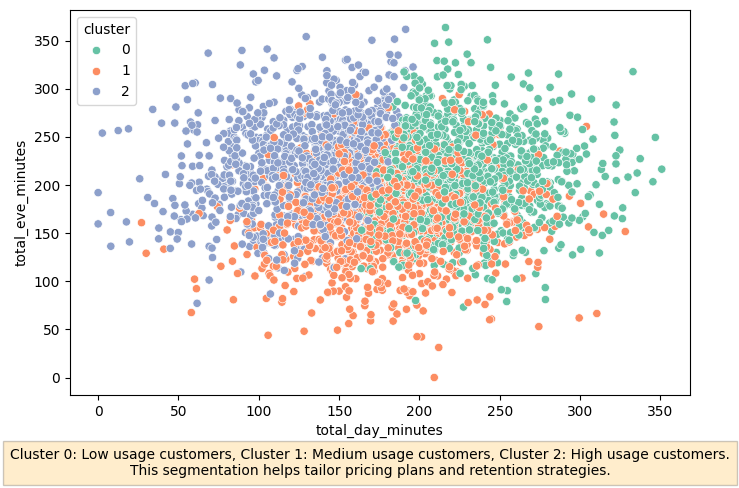

In [24]:
#Visualize Clusters
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='total_day_minutes',
    y='total_eve_minutes',
    hue='cluster',
    data=df_churn,
    palette='Set2'
)
plt.figtext(
    0.5, -0.05,
    "Cluster 0: Low usage customers, Cluster 1: Medium usage customers, Cluster 2: High usage customers.\n"
    "This segmentation helps tailor pricing plans and retention strategies.",
    ha="center",
    fontsize=10,
    bbox={"facecolor": "orange", "alpha": 0.2, "pad": 5}
)
plt.show()



In [26]:
# CONCLUSION

print("CONCLUSION\n")

print("""
This analysis applied time series techniques and clustering methods to extract meaningful insights
from stock price data and customer usage patterns.

Time Series Analysis:
- The stock closing price showed clear fluctuations over time with an observable trend.
- Decomposition separated the data into trend, seasonal, and residual components,
  providing a deeper understanding of underlying patterns.
- The moving average helped smooth short-term volatility and highlighted the overall direction
  of the stock price.

Clustering Analysis (K-Means):
- Customers were grouped into three clusters based on their call usage (day, evening, and night).
- The Elbow Method was used to determine the optimal number of clusters.
- The resulting clusters reveal distinct usage patterns among customers.

Overall Insight:
- Time series analysis helps in understanding and monitoring financial trends.
- Clustering enables segmentation of customers based on behavior, which can support
  more targeted analysis and decision-making.

Recommendation:
1. For Stock Prices:
- Focus on the general trend, not day-to-day price swings, when making pricing or investment decisions.
- Use simple moving averages to see if prices are generally going up or down.
- Avoid overreacting to small fluctuations; plan decisions based on the overall movement.

2. For Customer Strategy:
- Identify which group each customer belongs to (high, medium, low usage).
- Offer targeted communication or promotions: for example, reward high-usage customers, encourage medium users to increase usage, and engage low users to retain them.
- Use clusters to personalize services without needing complex analytics.

Overall, these insights allow the business to respond effectively to market behavior and customer patterns using simple, actionable steps derived from the analysis.
""")


CONCLUSION


This analysis applied time series techniques and clustering methods to extract meaningful insights
from stock price data and customer usage patterns.

Time Series Analysis:
- The stock closing price showed clear fluctuations over time with an observable trend.
- Decomposition separated the data into trend, seasonal, and residual components,
  providing a deeper understanding of underlying patterns.
- The moving average helped smooth short-term volatility and highlighted the overall direction
  of the stock price.

Clustering Analysis (K-Means):
- Customers were grouped into three clusters based on their call usage (day, evening, and night).
- The Elbow Method was used to determine the optimal number of clusters.
- The resulting clusters reveal distinct usage patterns among customers.

Overall Insight:
- Time series analysis helps in understanding and monitoring financial trends.
- Clustering enables segmentation of customers based on behavior, which can support
  more targ